In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pinxau1000/radioml2018/datasets.desktop
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.json
/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.txt
/kaggle/input/datasets/pinxau1000/radioml2018/LICENSE.TXT
/kaggle/input/datasets/pinxau1000/radioml2018/classes.txt


# 02 — Data Pipeline

This notebook builds the data pipeline for the project.

**What it produces:**
- A stratified train/test split (fixes the class-disjoint issue in the paper)
- A `RadioMLDataset` PyTorch class with lazy HDF5 loading and per-sample normalisation
- Verified `DataLoader` instances with timing benchmarks
- `dataset.py` — a reusable module imported by all downstream notebooks

**Why lazy loading?**
`X` is ~21 GB. Loading it fully crashes the kernel.
We instead store the row indices we need and read directly from HDF5
in `__getitem__`, which is called on demand by the DataLoader.

## 1. Setup

In [2]:
import os
import sys
import time
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ── paths ─────────────────────────────────────────────────────────────────────
HDF5_PATH   = None
for dirpath, _, filenames in os.walk("/kaggle/input"):
    for fname in filenames:
        if fname.endswith(".hdf5") or fname.endswith(".h5"):
            HDF5_PATH = os.path.join(dirpath, fname)

assert HDF5_PATH is not None, "HDF5 file not found under /kaggle/input"
print(f"Dataset : {HDF5_PATH}")

WORKING_DIR = "/kaggle/working"
os.makedirs(WORKING_DIR, exist_ok=True)

# ── device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

# ── dataset constants ─────────────────────────────────────────────────────────
MODULATIONS = [
    "OOK",       "4ASK",      "8ASK",      "BPSK",      "QPSK",
    "8PSK",      "16PSK",     "32PSK",     "16APSK",    "32APSK",
    "64APSK",    "128APSK",   "16QAM",     "32QAM",     "64QAM",
    "128QAM",    "256QAM",    "AM-SSB-WC", "AM-SSB-SC", "AM-DSB-WC",
    "AM-DSB-SC", "FM",        "GMSK",      "OQPSK",
]
SNR_VALUES  = list(range(-20, 32, 2))   # 26 levels
N_CLASSES   = len(MODULATIONS)          # 24
N_SNR       = len(SNR_VALUES)           # 26
N_PER_CELL  = 4096                      # samples per (class, SNR) cell

Dataset : /kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
Device  : cuda:0
GPU     : Tesla T4


## 2. Load labels and build index map

We load `Y` (class labels) and `Z` (SNR) fully — they are small (~510 MB total).

We then build an **index map**: a dictionary from `(class_index, snr_db)`
to the array of row positions in the HDF5 file for that cell.
This is the lookup structure used by `__getitem__` to fetch rows from `X`
without scanning the full array.

In [3]:
print("Loading Y and Z...")
with h5py.File(HDF5_PATH, "r") as f:
    Y = np.argmax(f["Y"][:], axis=1).astype(np.int8)
    Z = f["Z"][:, 0].astype(np.int16)

print(f"Y : {Y.shape}  |  Z : {Z.shape}")

# build (class, snr) → row indices lookup
print("Building index map...")
index_map = {
    (cls, snr): np.where((Y == cls) & (Z == snr))[0]
    for cls in range(N_CLASSES)
    for snr in SNR_VALUES
}

# sanity check — every cell must have exactly N_PER_CELL rows
sizes = [len(v) for v in index_map.values()]
assert min(sizes) == max(sizes) == N_PER_CELL, \
    f"Uneven cells: {min(sizes)} – {max(sizes)}"
print(f"Index map: {len(index_map)} cells × {N_PER_CELL} samples  ✓")

Loading Y and Z...
Y : (2555904,)  |  Z : (2555904,)
Building index map...
Index map: 624 cells × 4096 samples  ✓


## 3. Stratified split

The paper splits the dataset 50/50 by raw index. Because the file is
sorted by class, this gives classes 0–11 to the generator and classes
12–23 to the detector — they never overlap in modulation type.

We fix this with a **stratified split**: for every (class, SNR) cell
the first 2048 rows go to the generator split and the last 2048 to the
detector split. Both halves see all 24 classes and all 26 SNR levels.

In [4]:
HALF = N_PER_CELL // 2   # 2048

gen_idx = np.concatenate([
    index_map[(cls, snr)][:HALF]
    for cls in range(N_CLASSES)
    for snr in SNR_VALUES
]).astype(np.int32)

det_idx = np.concatenate([
    index_map[(cls, snr)][HALF:]
    for cls in range(N_CLASSES)
    for snr in SNR_VALUES
]).astype(np.int32)

overlap = len(np.intersect1d(gen_idx, det_idx))

print(f"Generator split : {len(gen_idx):,} samples")
print(f"Detector  split : {len(det_idx):,} samples")
print(f"Overlap         : {overlap}  {'✓' if overlap == 0 else '✗ ERROR'}")

# verify both splits are class-balanced
for name, idx in [("Generator", gen_idx), ("Detector", det_idx)]:
    counts = [(Y[idx] == c).sum() for c in range(N_CLASSES)]
    balanced = len(set(counts)) == 1
    print(f"{name} class balance: {counts[0]:,} per class  "
          f"{'✓' if balanced else '✗ UNBALANCED'}")

Generator split : 1,277,952 samples
Detector  split : 1,277,952 samples
Overlap         : 0  ✓
Generator class balance: 53,248 per class  ✓
Detector class balance: 53,248 per class  ✓


## 4. The Dataset class

`RadioMLDataset` is a standard PyTorch `Dataset`.

Key design decisions:
- **Lazy loading** — opens HDF5 in `__getitem__`, reads only the requested row
- **Per-sample normalisation** — z-score per channel (I and Q independently),
  because raw X values range roughly ±17, not ±1
- **Channels-first output** — returns shape `(2, 1024)` to match Conv1d convention
- Each item returns `(signal, class_index, snr_db)` so downstream code
  always has access to the label and SNR without a separate lookup

In [5]:
class RadioMLDataset(Dataset):
    """
    PyTorch Dataset for RadioML 2018.01A.

    Parameters
    ----------
    hdf5_path : str
        Path to the HDF5 file.
    indices : np.ndarray
        Row indices into the HDF5 file for this split.
    Y : np.ndarray
        Class label array for all samples (loaded from Y dataset).
    Z : np.ndarray
        SNR array for all samples (loaded from Z dataset).
    """

    def __init__(self, hdf5_path: str, indices: np.ndarray,
                 Y: np.ndarray, Z: np.ndarray):
        self.hdf5_path = hdf5_path
        # sort indices — h5py reads contiguous sorted rows much faster
        self.indices   = np.sort(indices)
        self.labels    = Y[self.indices]
        self.snrs      = Z[self.indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        row = int(self.indices[i])

        with h5py.File(self.hdf5_path, "r") as f:
            x = f["X"][row]                          # (1024, 2)  float32

        # channels-first: (2, 1024)
        x = x.T.astype(np.float32)

        # per-channel z-score normalisation
        mean = x.mean(axis=1, keepdims=True)
        std  = x.std(axis=1,  keepdims=True) + 1e-8
        x    = (x - mean) / std

        return (
            torch.from_numpy(x),           # (2, 1024)  float32
            int(self.labels[i]),           # class index
            float(self.snrs[i]),           # SNR in dB
        )

## 5. Instantiate and verify

In [6]:
ds_gen = RadioMLDataset(HDF5_PATH, gen_idx, Y, Z)
ds_det = RadioMLDataset(HDF5_PATH, det_idx, Y, Z)

print(f"Generator dataset : {len(ds_gen):,} samples")
print(f"Detector  dataset : {len(ds_det):,} samples")

# inspect one item
x0, label0, snr0 = ds_gen[0]
print(f"\nSample 0:")
print(f"  shape  : {x0.shape}        ← (channels, time)")
print(f"  dtype  : {x0.dtype}")
print(f"  class  : {label0}  ({MODULATIONS[label0]})")
print(f"  SNR    : {snr0:+.0f} dB")
print(f"  I mean : {x0[0].mean():.4f}  ← should be ≈ 0")
print(f"  I std  : {x0[0].std():.4f}   ← should be ≈ 1")
print(f"  Q mean : {x0[1].mean():.4f}")
print(f"  Q std  : {x0[1].std():.4f}")

Generator dataset : 1,277,952 samples
Detector  dataset : 1,277,952 samples

Sample 0:
  shape  : torch.Size([2, 1024])        ← (channels, time)
  dtype  : torch.float32
  class  : 0  (OOK)
  SNR    : -20 dB
  I mean : 0.0000  ← should be ≈ 0
  I std  : 1.0005   ← should be ≈ 1
  Q mean : -0.0000
  Q std  : 1.0005


## 6. DataLoaders and batch timing

`batch_size=512` matches the paper.  
`drop_last=True` keeps every batch the same size — required for the
gradient penalty in the WGAN training loop.  
`num_workers=2` is safe on Kaggle; more workers do not help here
because the bottleneck is HDF5 read latency, not CPU preprocessing.

We time the first batch to know the I/O cost before training.

In [7]:
BATCH_SIZE = 512

loader_gen = DataLoader(
    ds_gen,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True,
    drop_last   = True,
)

loader_det = DataLoader(
    ds_det,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True,
    drop_last   = True,
)

print(f"Generator loader : {len(loader_gen):,} batches per epoch")
print(f"Detector  loader : {len(loader_det):,} batches per epoch")

# time the first batch
it = iter(loader_gen)
t0 = time.time()
x_batch, label_batch, snr_batch = next(it)
t1 = time.time()

print(f"\nFirst batch:")
print(f"  shape       : {x_batch.shape}")
print(f"  fetch time  : {t1 - t0:.2f} s")
print(f"  labels[:4]  : {label_batch[:4].tolist()}")
print(f"  snrs[:4]    : {snr_batch[:4].tolist()}")

# move to GPU and verify
x_gpu = x_batch.to(DEVICE)
print(f"\nOn GPU : {x_gpu.shape}  on  {x_gpu.device}")
print(f"GPU memory used : "
      f"{torch.cuda.memory_allocated(DEVICE) / 1e6:.1f} MB")

Generator loader : 2,496 batches per epoch
Detector  loader : 2,496 batches per epoch

First batch:
  shape       : torch.Size([512, 2, 1024])
  fetch time  : 4.34 s
  labels[:4]  : [4, 6, 1, 3]
  snrs[:4]    : [-4.0, 26.0, 26.0, 10.0]

On GPU : torch.Size([512, 2, 1024])  on  cuda:0
GPU memory used : 4.2 MB


## 7. Batch visualisation

Always plot a batch before training. This confirms the DataLoader
is returning correctly normalised, correctly shaped signals.

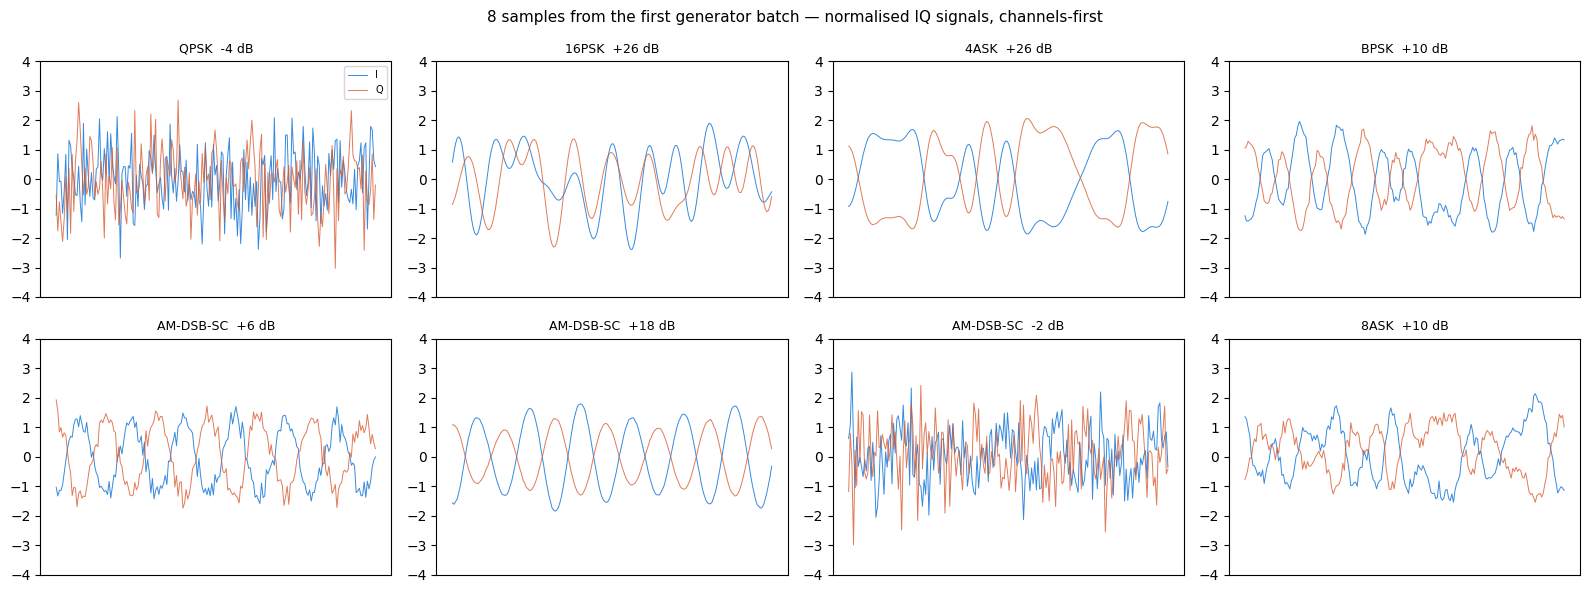

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, ax in enumerate(axes.flatten()):
    x   = x_batch[i].numpy()          # (2, 1024)
    cls = int(label_batch[i])
    snr = float(snr_batch[i])

    ax.plot(x[0, :200], linewidth=0.7, color="#378ADD", label="I")
    ax.plot(x[1, :200], linewidth=0.7, color="#D85A30", label="Q", alpha=0.8)
    ax.set_title(f"{MODULATIONS[cls]}  {snr:+.0f} dB", fontsize=9)
    ax.set_ylim(-4, 4)
    ax.set_xticks([])

axes[0, 0].legend(fontsize=7)
fig.suptitle("8 samples from the first generator batch — "
             "normalised IQ signals, channels-first", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, "pipeline_batch_sample.png"),
            dpi=120, bbox_inches="tight")
plt.show()

## 8. Export dataset.py

We write the Dataset class and all constants to a standalone Python module.
Every downstream notebook imports from this file instead of redefining things.

```python
import sys
sys.path.append("/kaggle/working")
from dataset import RadioMLDataset, MODULATIONS, SNR_VALUES, get_loaders
```

In [9]:
MODULE_PATH = os.path.join(WORKING_DIR, "dataset.py")

code = '''"""
dataset.py — RadioML 2018.01A data pipeline
Generated by 02_data_pipeline.ipynb
"""

import os
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ── constants ─────────────────────────────────────────────────────────────────
MODULATIONS = [
    "OOK",       "4ASK",      "8ASK",      "BPSK",      "QPSK",
    "8PSK",      "16PSK",     "32PSK",     "16APSK",    "32APSK",
    "64APSK",    "128APSK",   "16QAM",     "32QAM",     "64QAM",
    "128QAM",    "256QAM",    "AM-SSB-WC", "AM-SSB-SC", "AM-DSB-WC",
    "AM-DSB-SC", "FM",        "GMSK",      "OQPSK",
]
SNR_VALUES  = list(range(-20, 32, 2))
N_CLASSES   = len(MODULATIONS)
N_SNR       = len(SNR_VALUES)
N_PER_CELL  = 4096


# ── dataset ───────────────────────────────────────────────────────────────────
class RadioMLDataset(Dataset):
    """
    PyTorch Dataset for RadioML 2018.01A.

    Parameters
    ----------
    hdf5_path : str        Path to the HDF5 file.
    indices   : np.ndarray Row indices for this split.
    Y         : np.ndarray Class label array (all samples).
    Z         : np.ndarray SNR array (all samples).
    """

    def __init__(self, hdf5_path: str, indices: np.ndarray,
                 Y: np.ndarray, Z: np.ndarray):
        self.hdf5_path = hdf5_path
        self.indices   = np.sort(indices)
        self.labels    = Y[self.indices]
        self.snrs      = Z[self.indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        with h5py.File(self.hdf5_path, "r") as f:
            x = f["X"][int(self.indices[i])]          # (1024, 2)

        x = x.T.astype(np.float32)                    # (2, 1024)
        mean = x.mean(axis=1, keepdims=True)
        std  = x.std(axis=1,  keepdims=True) + 1e-8
        x    = (x - mean) / std

        return (
            torch.from_numpy(x),
            int(self.labels[i]),
            float(self.snrs[i]),
        )


# ── split builder ─────────────────────────────────────────────────────────────
def build_splits(Y: np.ndarray, Z: np.ndarray):
    """
    Build stratified generator / detector split indices.
    For each (class, SNR) cell: first 2048 rows → generator,
    last 2048 rows → detector.
    Both splits cover all 24 classes and all 26 SNR levels.
    """
    half = N_PER_CELL // 2
    gen_idx, det_idx = [], []
    for cls in range(N_CLASSES):
        for snr in SNR_VALUES:
            rows = np.where((Y == cls) & (Z == snr))[0]
            gen_idx.append(rows[:half])
            det_idx.append(rows[half:])
    return (np.concatenate(gen_idx).astype(np.int32),
            np.concatenate(det_idx).astype(np.int32))


# ── convenience factory ───────────────────────────────────────────────────────
def get_loaders(hdf5_path: str, batch_size: int = 512, num_workers: int = 2):
    """
    Load Y and Z, build splits, return (loader_gen, loader_det, meta).

    meta is a dict with keys: Y, Z, gen_idx, det_idx, MODULATIONS, SNR_VALUES.
    """
    with h5py.File(hdf5_path, "r") as f:
        Y = np.argmax(f["Y"][:], axis=1).astype(np.int8)
        Z = f["Z"][:, 0].astype(np.int16)

    gen_idx, det_idx = build_splits(Y, Z)

    ds_gen = RadioMLDataset(hdf5_path, gen_idx, Y, Z)
    ds_det = RadioMLDataset(hdf5_path, det_idx, Y, Z)

    kw = dict(batch_size=batch_size, num_workers=num_workers,
              pin_memory=True, drop_last=True, shuffle=True)

    return (
        DataLoader(ds_gen, **kw),
        DataLoader(ds_det, **kw),
        dict(Y=Y, Z=Z, gen_idx=gen_idx, det_idx=det_idx,
             MODULATIONS=MODULATIONS, SNR_VALUES=SNR_VALUES),
    )
'''

with open(MODULE_PATH, "w") as f:
    f.write(code)

print(f"Saved: {MODULE_PATH}")
print(f"Size : {os.path.getsize(MODULE_PATH) / 1e3:.1f} KB")

# verify it imports and works correctly
sys.path.insert(0, WORKING_DIR)
from dataset import get_loaders

loader_gen_v, loader_det_v, meta = get_loaders(HDF5_PATH)
x_v, y_v, z_v = next(iter(loader_gen_v))
print(f"\nImport check — batch shape: {x_v.shape}  ✓")

Saved: /kaggle/working/dataset.py
Size : 4.1 KB

Import check — batch shape: torch.Size([512, 2, 1024])  ✓


## Summary

| Output | Description |
|--------|-------------|
| `dataset.py` | Reusable module — import in all downstream notebooks |
| `RadioMLDataset` | Lazy HDF5 loader, per-sample normalisation, channels-first |
| `build_splits()` | Stratified 50/50 split across all 24 classes and 26 SNR levels |
| `get_loaders()` | One-line factory — returns both DataLoaders and metadata |

**Usage in the next notebook:**
```python
import sys
sys.path.insert(0, "/kaggle/working")
from dataset import get_loaders, MODULATIONS, SNR_VALUES

loader_gen, loader_det, meta = get_loaders(HDF5_PATH)
```

**Next:** `03_ambiguity_function.ipynb` — implement the differentiable
ambiguity function loss in PyTorch and verify gradients flow through it.